# Modelado Estocástico
## Clase 06 - Procesos autorregresivos

* Preparación del Entorno y Librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.gridspec as gridspec

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

## Reparametrizaciones

### El Concepto de Ruido Blanco (White Noise) o $\epsilon_{t}$

Para que un proceso se considere ruido blanco, debe cumplir tres condiciones estrictas:
- Su esperanza matemática debe ser igual a cero para todo $t$.  
- La varianza del proceso debe ser constante a lo largo del tiempo.
- Las covarianzas entre las distintas observaciones (autocorrelación) deben ser nulas para cualquier rezago distinto de cero.

Fabricamos un ejemplo:

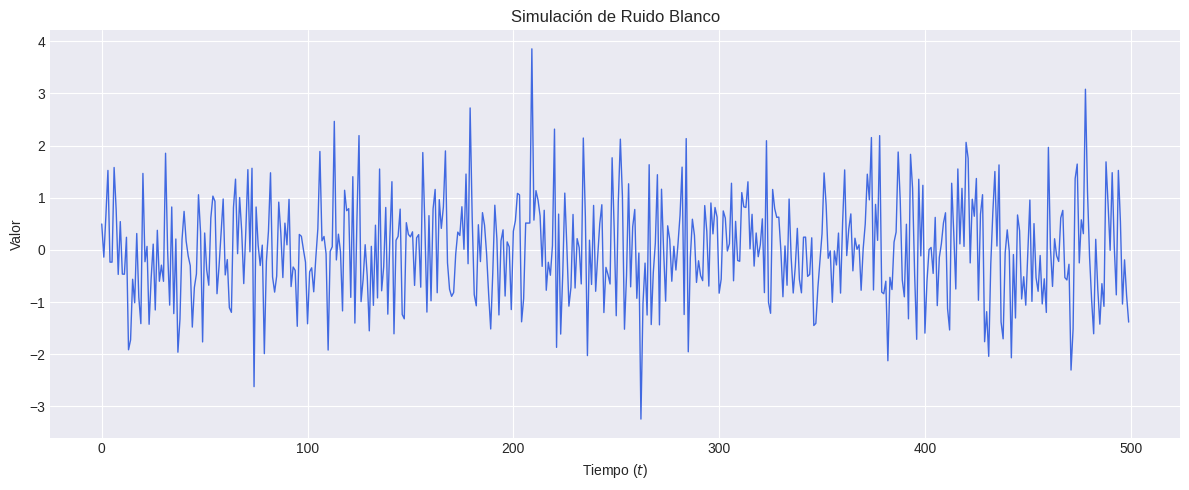

In [ ]:
np.random.seed(42)

T = 500
epsilon = np.random.normal(loc=0, scale=1, size=T)

plt.plot(epsilon, color='royalblue', linewidth=1)
plt.title('Simulación de Ruido Blanco')
plt.xlabel('Tiempo ($t$)')
plt.ylabel('Valor')
plt.tight_layout()
plt.show()

## Procesos Autorregresivos (AR) y de Medias Móviles (MA)

Dado que estimar empíricamente todas las covarianzas de una serie de tiempo es matemáticamente imposible por la falta de grados de libertad, recurrimos a reparametrizar los errores.

Esto significa representar los errores con una estructura específica que requiera estimar pocos parámetros.  

### Procesos Autorregresivos (AR)

#### **Proceso AR(1)**

El valor actual depende de su rezago inmediato ponderado por un coeficiente $\rho$, más un término de error de ruido blanco.
 $$AR(1):  u_t = \rho  \ u_{t-1} + \epsilon_t$$

Podríamos generar un proceso AR(*1*) de forma manual aplicando la fórmula:

In [ ]:
rho = 0.7
n = T

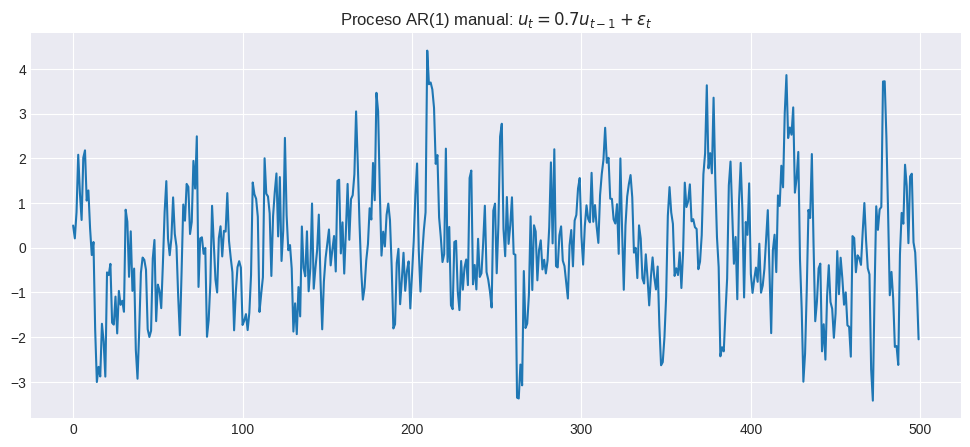

In [ ]:
def proceso_ar1(rho, u_prev, error):
    return rho * u_prev + error

u = np.zeros(T)
u[0] = epsilon[0]

for i in range(1, n):
    error = epsilon[i]
    u[i] = proceso_ar1(rho, u[i-1], error)

ar1manual = u

plt.plot(ar1manual)
plt.title(r'Proceso AR(1) manual: $u_t = 0.7 u_{t-1} + \epsilon_t$')
plt.show()

Al forzar $u_0 = \epsilon_0$, la varianza de esa primera observación simulada es simplemente $\sigma^2$ (la varianza del ruido blanco). Sin embargo, la varianza teórica de un proceso $AR(1)$ estacionario es:$$\operatorname{Var}(u_t) = \frac{\sigma^2}{1 - \rho^2}$$

Para un desarrollo más riguroso de la generación del proceso podemos utilizar la biblioteca `statsmodels`. Para evitar que los primeros datos de la serie tengan una varianza menor y distorsionen el comportamiento estacionario, los simuladores profesionales usan un concepto llamado Burn-in (período de calentamiento), por eso vamos a obtener resultados diferentes.

https://www.statsmodels.org/devel/generated/statsmodels.tsa.arima_process.ArmaProcess.html

Statsmodels requiere que los polinomios AR y MA incluyan el rezago cero (el valor actual), que siempre se define como 1. Además, los signos de la parte AR se ingresan invertidos.

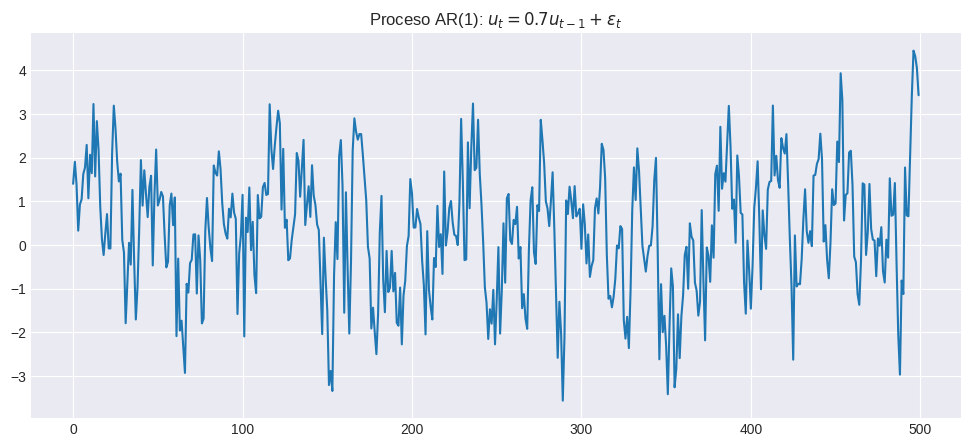

In [ ]:
ar1_params = np.array([1, -rho])
ma_params_base = np.array([1])
ar1_process = ArmaProcess(ar1_params, ma_params_base)
u_ar1 = ar1_process.generate_sample(nsample=T)

plt.plot(u_ar1)
plt.title(r'Proceso AR(1): $u_t = 0.7 u_{t-1} + \epsilon_t$')
plt.show()

#### $AR(2): u_t = \rho_1 * u_{t-1} + \rho_2 * u_{t-2} + \epsilon_t$

Por ejemplo, $u_t = 0.7 * u_{t-1}  -0.2 * u_{t-2} + \epsilon_t$ se generará con los siguientes parámetros:

In [ ]:
rho2 = -0.2
ar2_params = np.array([1, -rho, -rho2,])
ma = np.array([1])

### Procesos de Medias móviles



#### **Proceso MA(1)**

El valor actual depende de un parámetro $\theta$ multiplicado por el ruido blanco del período anterior, sumado al ruido blanco actual

$$MA(1): u_t = \theta \epsilon_{t-1} + \epsilon_t$$

Si quisiéramos generarlo manualmente:

In [ ]:
theta1 = 0.8

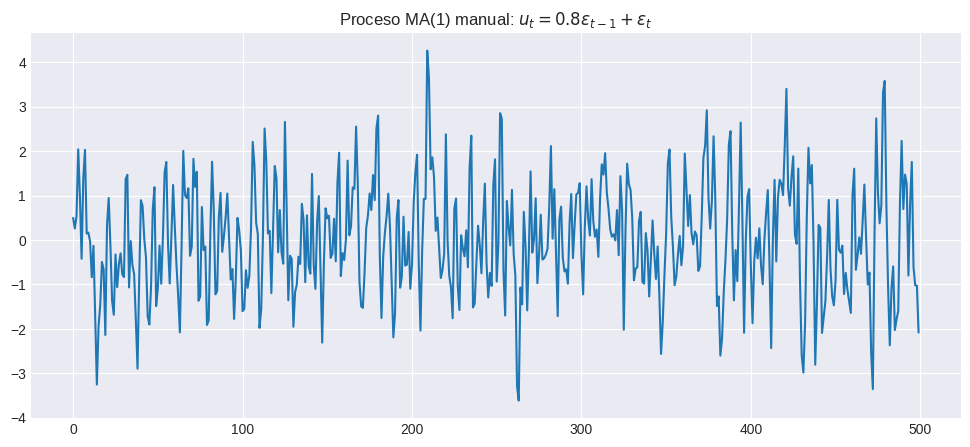

In [ ]:
y_ma1 = np.zeros(n)
y_ma1[0] = epsilon[0]

for i in range(1, n):
    y_ma1[i] = epsilon[i] + theta1 * epsilon[i - 1]

ma1_manual = y_ma1

plt.plot(ma1_manual)
plt.title(r'Proceso MA(1) manual: $u_t = 0.8 \epsilon_{t-1} + \epsilon_t$')
plt.show()



#### Generación de MA(1) utilizando Statsmodels:

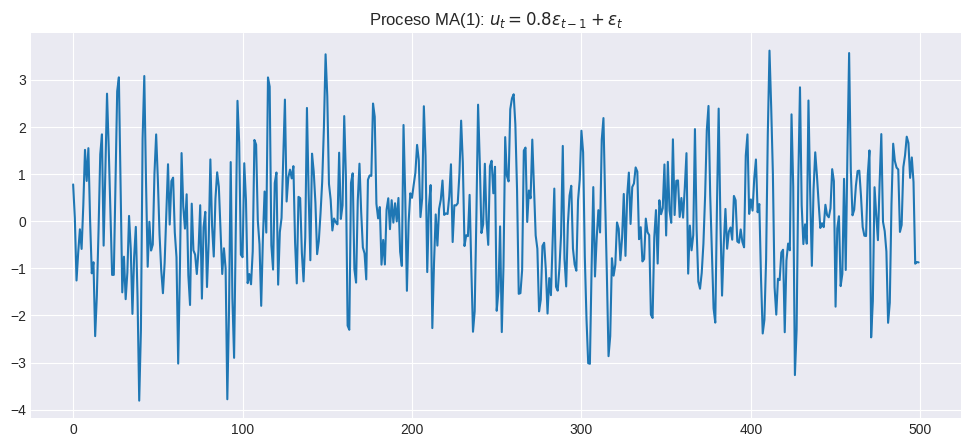

In [ ]:
ar_params_base = np.array([1])
ma1_params = np.array([1, theta1])
ma1_process = ArmaProcess(ar_params_base, ma1_params)
uma1 = ma1_process.generate_sample(nsample=T)

plt.plot(uma1)
plt.title(r'Proceso MA(1): $u_t = 0.8 \epsilon_{t-1} + \epsilon_t$')
plt.show()

#### MA(2) y MA(4)

$MA(2): u_t = \theta_1  \epsilon_{t-1} + \theta_2  \epsilon_{t-2} + \epsilon_t$



$MA(4): u_t =  \theta_1  \epsilon_{t-1} + \theta_2  \epsilon_{t-2} +\theta_3  \epsilon_{t-3} + \theta_4  \epsilon_{t-4} + \epsilon_t$  

Los parámetros necesarios serán:

In [ ]:
theta2 = -0.4
ar = np.array([1])
theta_ma2 = np.array([1, theta1, theta2])
theta_ma4 = np.array([1, theta1, theta2, 0.3, 0.2])

### Procesos ARMA



#### $ARMA(1,1): u_t = \rho  u_{t-1} + \theta  e_{t-1} + e_t$

In [ ]:
ar_params_arma = np.array([1, -rho])
ma_params_arma = np.array([1, theta1])

proceso_arma = ArmaProcess(ar, ma)
y_arma = proceso_arma.generate_sample(500)

### Generalización

Dado que todos los procesos autorregresivos ejemplificados reciben los parámetros AR y MA como dos arreglos con los valores de $\rho_i$ y $\theta_i$, se puede generalizar el cálculo con una función auxiliar.

In [ ]:
def simular_proceso(ar, ma, n=500, seed=123):
    np.random.seed(seed)

    proceso = ArmaProcess(ar, ma)

    return proceso.generate_sample(nsample=n)

## Gráfico comparativo de procesos autorregresivos con Autocorrelation Function y Partial Autocorrelation Function

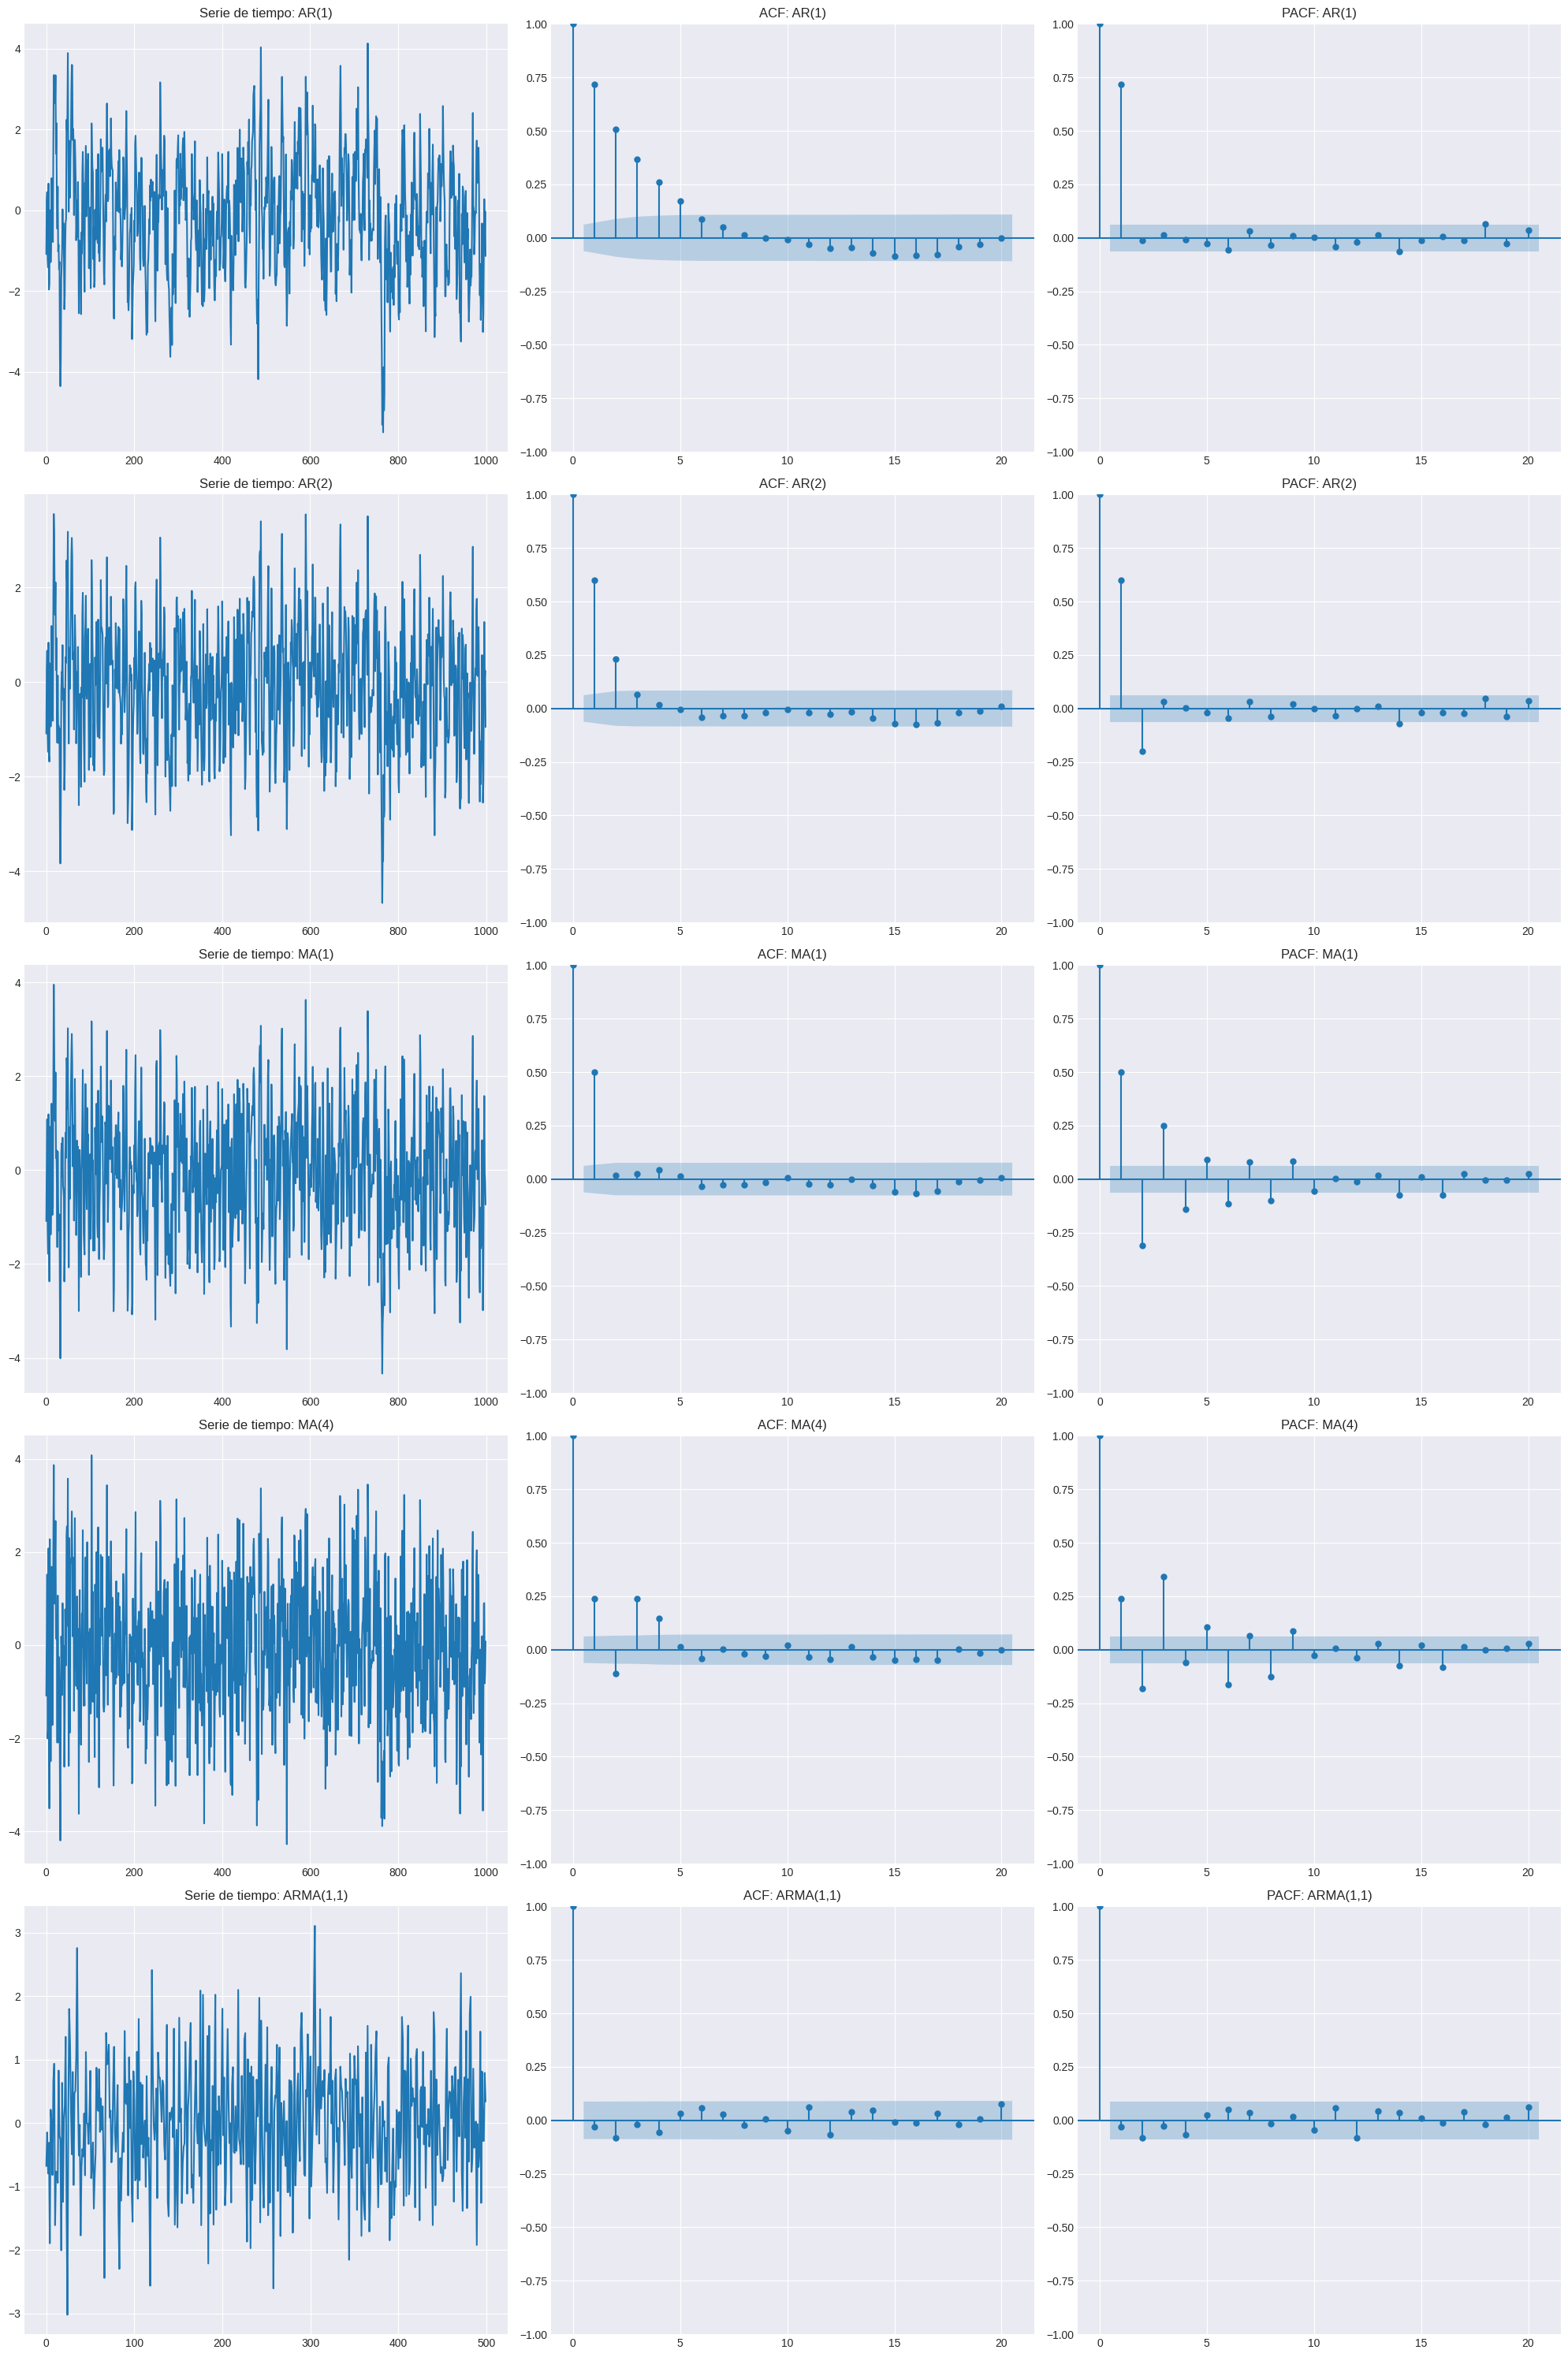

In [ ]:
n = 1000
np.random.seed(123)
series = {
    'AR(1)': simular_proceso(ar1_params, ma_params_base,n),
    'AR(2)': simular_proceso(ar2_params, ma_params_base,n),
    'MA(1)': simular_proceso(ar_params_base, ma1_params,n),
    'MA(4)': simular_proceso(ar_params_base, theta_ma4,n),
    'ARMA(1,1)': y_arma,
}

fig = plt.figure(figsize=(20, 30))

gs = gridspec.GridSpec(len(series), 3, figure=fig)


for i, (name, y) in enumerate(series.items()):
    ax0 = fig.add_subplot(gs[i, 0])
    ax0.plot(y)
    ax0.set_title(f"Serie de tiempo: {name}")

    ax1 = fig.add_subplot(gs[i, 1])
    plot_acf(y, ax=ax1, lags=20, title=f"ACF: {name}")

    ax2 = fig.add_subplot(gs[i, 2])
    plot_pacf(y, ax=ax2, lags=20, title=f"PACF: {name}")

fig.subplots_adjust(
    hspace=0.8,
    wspace=0.4
)
plt.tight_layout()
plt.show()